In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import random
import os
import joblib


SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [2]:
df = pd.read_csv('../data/CreditPrediction.csv')
df = df.drop(columns=['CLIENTNUM', 'Unnamed: 19'])
df = df[(df['Total_Amt_Chng_Q4_Q1'] <= 2.8) & (df['Customer_Age'] <= 80)]
print(f'Размер данных после удаления аномалий: {df.shape[0]}')

Размер данных после удаления аномалий: 10148


In [3]:
target_col = "Credit_Limit"
num_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col != target_col]
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(num_cols)
print(cat_cols)

['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


In [4]:
print(f'Уникальные значения для категориальных колонок:')

for col_name in cat_cols:
    print(f'{col_name} - {df[col_name].unique()}', end='\n\n')

Уникальные значения для категориальных колонок:
Gender - ['M' 'F' nan]

Education_Level - ['High School' 'Graduate' 'Uneducated' 'Unknown' 'Post-Graduate'
 'Doctorate' 'College']

Marital_Status - ['Married' nan 'Unknown' 'Single' 'Divorced']

Income_Category - ['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']

Card_Category - ['Blue' nan 'Gold' 'Silver' 'Platinum']



In [5]:
for col_name in cat_cols:
    df[col_name] = df[col_name].fillna('Unknown')

In [6]:
for col_name in num_cols:
    df[col_name] = df[col_name].fillna(df[col_name].median())

In [7]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f'Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)')

Train: 6088 (60.0%)
Validation: 2030 (20.0%)
Test: 2030 (20.0%)


In [8]:
y_train_log = np.log(y_train.values)
y_val_log   = np.log(y_val.values)
y_test_log  = np.log(y_test.values)

X_train_cb = X_train.copy()
X_val_cb = X_val.copy()
X_test_cb = X_test.copy()

print(f"Shape X_train: {X_train_cb.shape}")
print(f"Категориальные колонки: {cat_cols}")

Shape X_train: (6088, 17)
Категориальные колонки: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


In [ ]:
cb_model = CatBoostRegressor(
    iterations=100,
    depth=8,
    learning_rate=0.1,
    random_state=SEED,
    verbose=False,
    loss_function='RMSE',
    cat_features=cat_cols
)

print("Обучение CatBoost модели...")
cb_model.fit(X_train_cb, y_train_log, eval_set=[(X_val_cb, y_val_log)])
print("Обучение завершено!")

Обучение CatBoost модели...
Обучение завершено!


In [9]:
def plot_feature_importance(model, X_train, top_n=15):
    """Рисует график важности признаков"""
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = feature_importance.head(top_n)
    ax.barh(range(len(top_features)), top_features['importance'].values)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'].values)
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(f'Top {top_n} Feature Importance', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return feature_importance

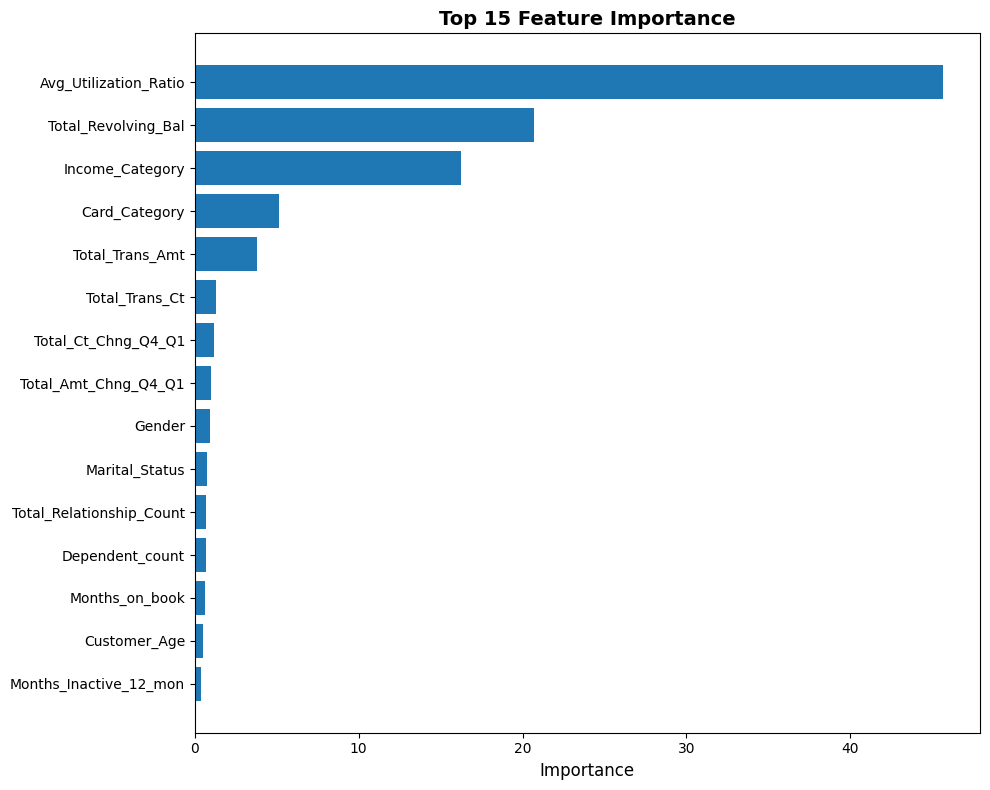

In [14]:
y_train_pred_log = cb_model.predict(X_train_cb)
y_val_pred_log = cb_model.predict(X_val_cb)
y_test_pred_log = cb_model.predict(X_test_cb)

y_train_pred = np.exp(y_train_pred_log)
y_val_pred = np.exp(y_val_pred_log)
y_test_pred = np.exp(y_test_pred_log)

y_train_actual = np.exp(y_train_log)
y_val_actual = np.exp(y_val_log)
y_test_actual = np.exp(y_test_log)

feature_importance = plot_feature_importance(cb_model, X_train_cb, top_n=15)

In [15]:
def calculate_cb_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'\n{dataset_name}:')
    print(f'  MSE:   {mse:.4f}')
    print(f'  RMSE:  {rmse:.4f}')
    print(f'  MAE:   {mae:.4f}')
    print(f'  R²:    {r2:.4f}')
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

print('=' * 50)
print('Метрики CatBoost модели')
print('=' * 50)

train_cb_metrics = calculate_cb_metrics(y_train_actual, y_train_pred, 'TRAIN')
val_cb_metrics = calculate_cb_metrics(y_val_actual, y_val_pred, 'VALIDATION')
test_cb_metrics = calculate_cb_metrics(y_test_actual, y_test_pred, 'TEST')

print('\n' + '=' * 50)

joblib.dump(cb_model, '../artifacts/model_catboost.pkl')
print("\nМодель сохранена в '../artifacts/model_catboost.pkl'")

Метрики CatBoost модели

TRAIN:
  MSE:   9706265.8531
  RMSE:  3115.4881
  MAE:   1289.2813
  R²:    0.8851

VALIDATION:
  MSE:   12251483.1327
  RMSE:  3500.2119
  MAE:   1444.7108
  R²:    0.8435

TEST:
  MSE:   10766896.0610
  RMSE:  3281.2949
  MAE:   1425.0184
  R²:    0.8670


Модель сохранена в '../artifacts/model_catboost.pkl'


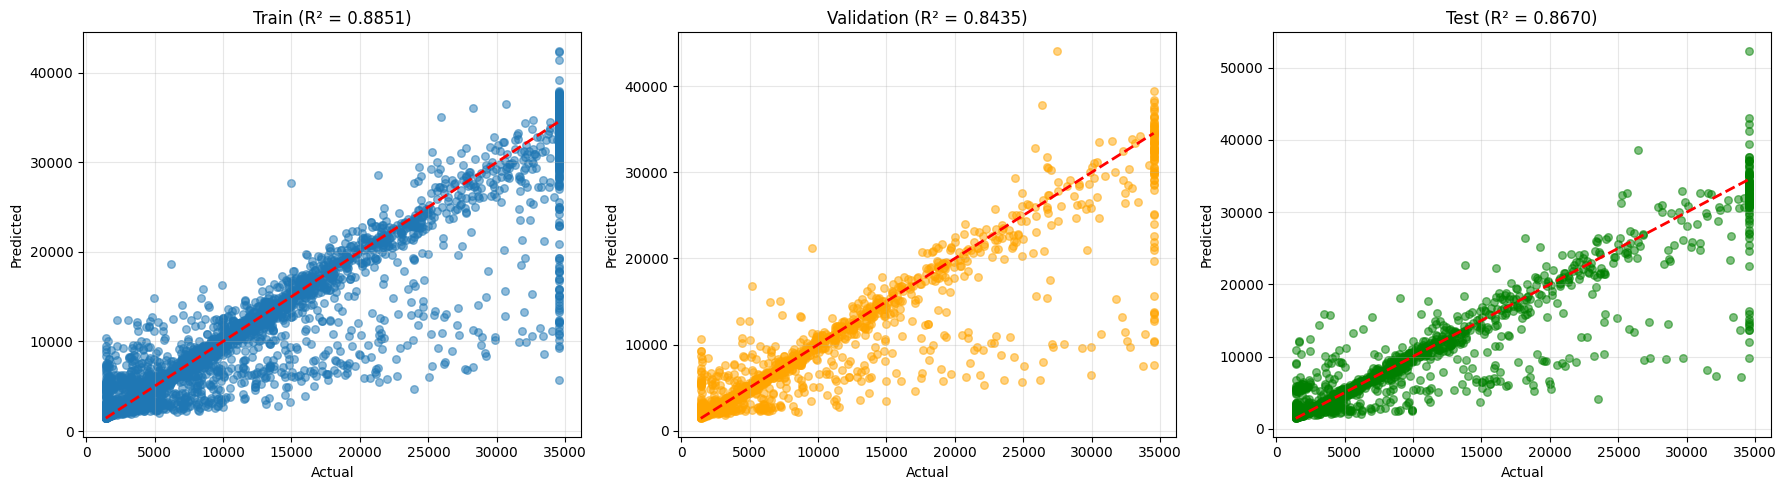

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_train_actual, y_train_pred, alpha=0.5, s=30)
axes[0].plot([y_train_actual.min(), y_train_actual.max()], 
             [y_train_actual.min(), y_train_actual.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Train (R² = {train_cb_metrics["R2"]:.4f})')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_val_actual, y_val_pred, alpha=0.5, s=30, color='orange')
axes[1].plot([y_val_actual.min(), y_val_actual.max()], 
             [y_val_actual.min(), y_val_actual.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Validation (R² = {val_cb_metrics["R2"]:.4f})')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(y_test_actual, y_test_pred, alpha=0.5, s=30, color='green')
axes[2].plot([y_test_actual.min(), y_test_actual.max()], 
             [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title(f'Test (R² = {test_cb_metrics["R2"]:.4f})')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import optuna
import joblib

optuna.logging.set_verbosity(optuna.logging.WARNING)

print("=" * 50)
print("Тюнинг гиперпараметров CatBoost (Optuna)")
print("=" * 50)

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000, step=100),
        'depth': trial.suggest_int('depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 6),
        'random_state': SEED,
        'loss_function': 'RMSE',
        'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),
    }
    
    model = CatBoostRegressor(**params, verbose=False)
    model.fit(X_train_cb, y_train_log, cat_features=cat_cols, eval_set=[(X_val_cb, y_val_log)])
    
    score = model.score(X_val_cb, y_val_log)
    return score

study = optuna.create_study(
    direction='maximize', 
    sampler=optuna.samplers.TPESampler(seed=SEED)
)

print("\nЗапуск оптимизации...")
study.optimize(objective, n_trials=30, n_jobs=1, show_progress_bar=True)

print(f"\nЛучшие параметры: {study.best_params}")
print(f"Лучший R²: {study.best_value:.4f}")

best_params = study.best_params.copy()
best_params['verbose'] = False
best_params['loss_function'] = 'RMSE'
best_params['random_state'] = SEED

best_cb = CatBoostRegressor(**best_params)
best_cb.fit(X_train_cb, y_train_log, cat_features=cat_cols, eval_set=[(X_val_cb, y_val_log)])

y_val_pred_best = np.exp(best_cb.predict(X_val_cb))
y_test_pred_best = np.exp(best_cb.predict(X_test_cb))

print(f"\nValidation | R²: {r2_score(y_val_actual, y_val_pred_best):.4f} | RMSE: {np.sqrt(mean_squared_error(y_val_actual, y_val_pred_best)):.4f}")
print(f"Test      | R²: {r2_score(y_test_actual, y_test_pred_best):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test_actual, y_test_pred_best)):.4f}")

joblib.dump(best_cb, '../artifacts/model_catboost_best_optuna.pkl')
print("\nМодель сохранена в '../artifacts/model_catboost_best_optuna.pkl'")

Тюнинг гиперпараметров CatBoost (Optuna)

Запуск оптимизации...


Best trial: 20. Best value: 0.863761: 100%|██████████| 30/30 [14:18<00:00, 28.60s/it]



Лучшие параметры: {'iterations': 700, 'depth': 8, 'learning_rate': 0.10721058483355914, 'l2_leaf_reg': 5.886332327975389, 'grow_policy': 'Lossguide'}
Лучший R² (CV): 0.8638

Validation | R²: 0.8548 | RMSE: 3371.4451
Test      | R²: 0.8675 | RMSE: 3275.1667

Модель сохранена в '../artifacts/model_catboost_best_optuna.pkl'
